THE CONTROL FOR CERVICAL CANCER PROJECT WITH THE PROPOSED (6) SIX MACHINE LEARNING MODELS AND GRID WITHOUT FEATURE SELECTORS.

In [ ]:
# 1. Import Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import MinMaxScaler, LabelEncoder
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score, roc_curve, precision_recall_curve, auc

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier

from imblearn.over_sampling import SMOTE

import warnings
warnings.filterwarnings('ignore')



In [ ]:
# === 2. Load Dataset ===
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
# 3. Loading the dataset
df = pd.read_csv("//content/drive/MyDrive/risk_factors_cervical_cancer.csv")

In [ ]:
print(df())

In [ ]:
# 3. Initial Exploration
print(df.head())
print("\nDataset shape:", df.shape)
print("\nData types:\n", df.dtypes)
print("\nMissing values:\n", df.isnull().sum())



   Age  Number of sexual partners  First sexual intercourse  \
0   18                        4.0                      15.0   
1   15                        1.0                      14.0   
2   34                        1.0                       NaN   
3   52                        5.0                      16.0   
4   46                        3.0                      21.0   

   Num of pregnancies  Smokes  Smokes (years)  Smokes (packs/year)  \
0                 1.0     0.0             0.0                  0.0   
1                 1.0     0.0             0.0                  0.0   
2                 1.0     0.0             0.0                  0.0   
3                 4.0     1.0            37.0                 37.0   
4                 4.0     0.0             0.0                  0.0   

   Hormonal Contraceptives  Hormonal Contraceptives (years)  IUD  ...  \
0                      0.0                              0.0  0.0  ...   
1                      0.0                            

In [ ]:
# 4. Handling missing values without dropping rows

print("Missing values before imputation:\n", df.isnull().sum())

# Fill numerical columns with median
df.fillna(df.median(numeric_only=True), inplace=True)

# Fill categorical columns with mode
for col in df.columns:
    if df[col].dtype == 'object':
        df[col].fillna(df[col].mode()[0], inplace=True)

print("Missing values after imputation:\n", df.isnull().sum())
print("Shape after dropping missing values:", df.shape)

Missing values before imputation:
 Age                                   0
Number of sexual partners             0
First sexual intercourse              0
Num of pregnancies                    0
Smokes                                0
Smokes (years)                        0
Smokes (packs/year)                   0
Hormonal Contraceptives               0
Hormonal Contraceptives (years)       0
IUD                                   0
IUD (years)                           0
STDs                                  0
STDs (number)                         0
STDs:condylomatosis                   0
STDs:cervical condylomatosis          0
STDs:vaginal condylomatosis           0
STDs:vulvo-perineal condylomatosis    0
STDs:syphilis                         0
STDs:pelvic inflammatory disease      0
STDs:genital herpes                   0
STDs:molluscum contagiosum            0
STDs:AIDS                             0
STDs:HIV                              0
STDs:Hepatitis B                      0
STDs:

In [ ]:
# 5. Encode Target Variable (e.g., 'Biopsy')
df['Biopsy'] = LabelEncoder().fit_transform(df['Biopsy'])


In [ ]:
# 6. Normalize Numerical Features
X = df.drop('Biopsy', axis=1)
y = df['Biopsy']
X_scaled = pd.DataFrame(MinMaxScaler().fit_transform(X), columns=X.columns)



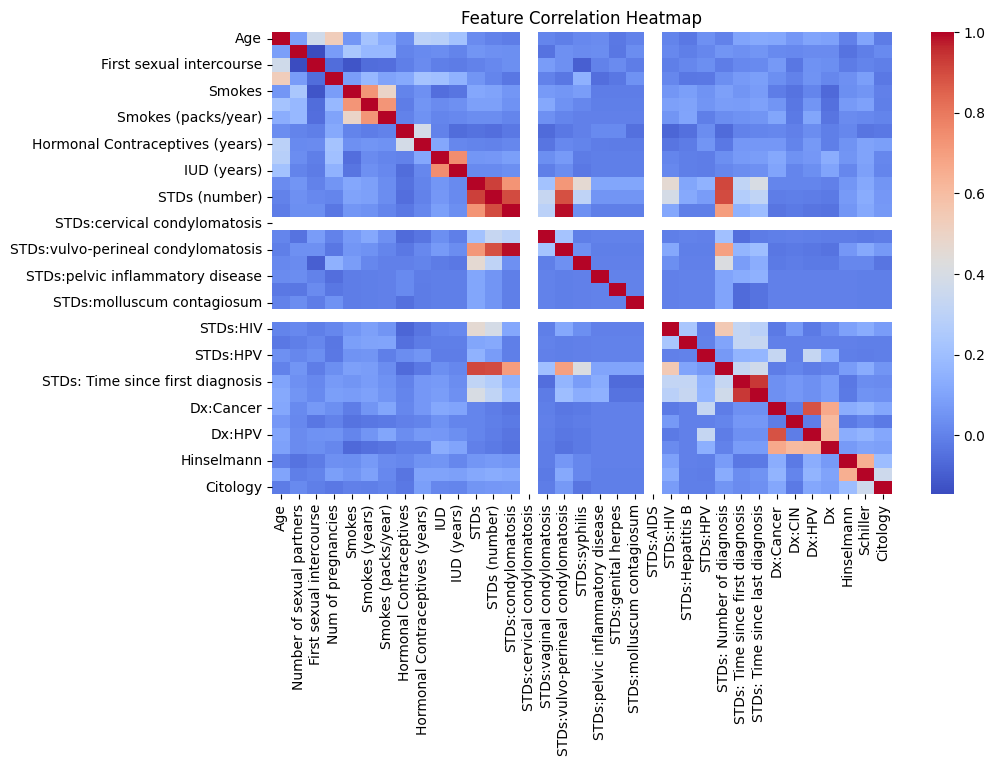

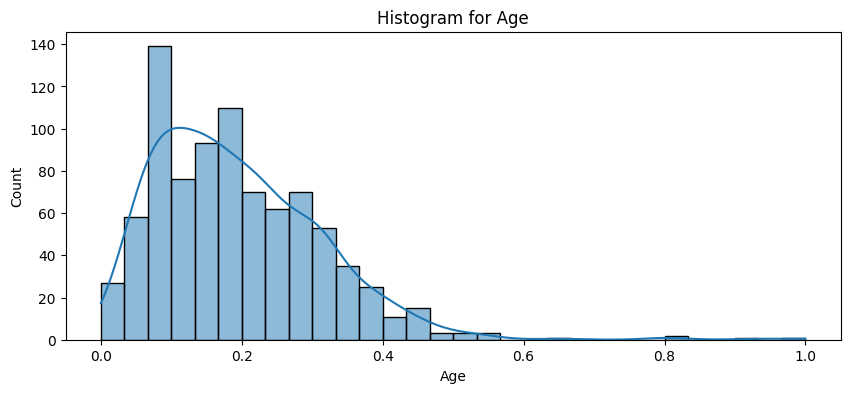

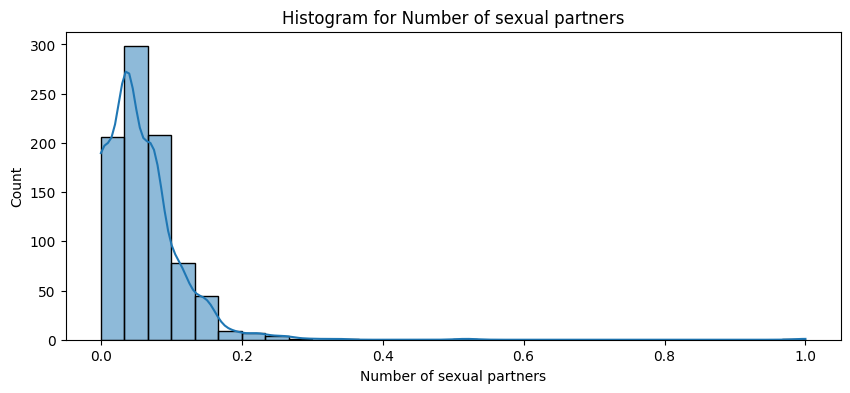

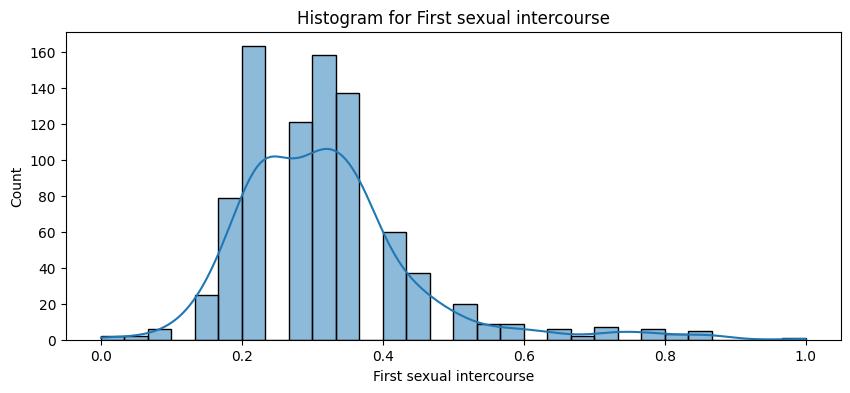

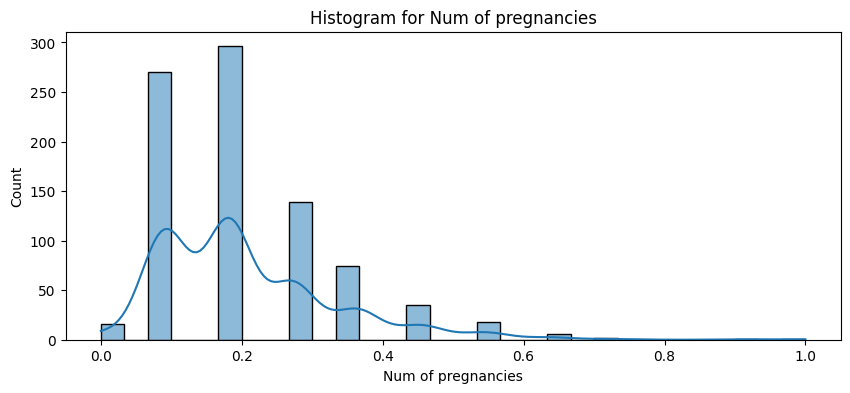

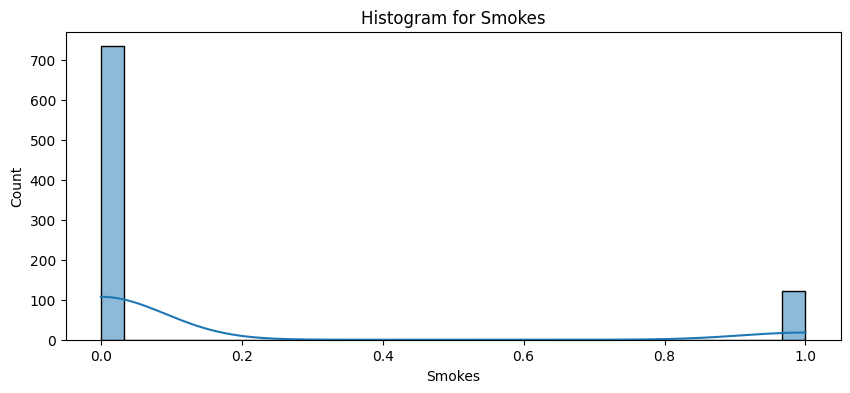

In [ ]:
# 7. Visualizations
plt.figure(figsize=(10, 6))
sns.heatmap(X_scaled.corr(), annot=False, cmap='coolwarm')
plt.title("Feature Correlation Heatmap")
plt.show()

for col in X_scaled.columns[:5]:  # limit to first 5 features for brevity
    plt.figure(figsize=(10,4))
    sns.histplot(X_scaled[col], kde=True, bins=30)
    plt.title(f'Histogram for {col}')
    plt.show()



In [ ]:
# 8. Handle Class Imbalance using SMOTE
X_resampled, y_resampled = SMOTE(random_state=42).fit_resample(X_scaled, y)

# 9. Train-Test Split
X_train, X_test, y_train, y_test = train_test_split(X_resampled, y_resampled, test_size=0.2, random_state=42, stratify=y_resampled)



In [ ]:
# 10. Define Models
models = {
    "Logistic Regression": LogisticRegression(),
    "Decision Tree": DecisionTreeClassifier(random_state=42),
    "K-Nearest Neighbors": KNeighborsClassifier(),
    "Naive Bayes": GaussianNB(),
    "Support Vector Machine": SVC(probability=True),
    "Random Forest": RandomForestClassifier(random_state=42)
}



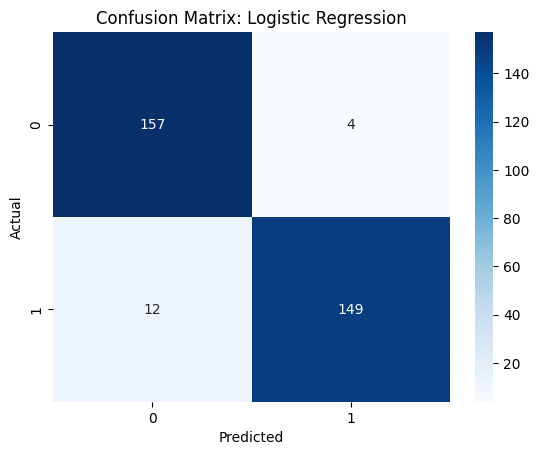

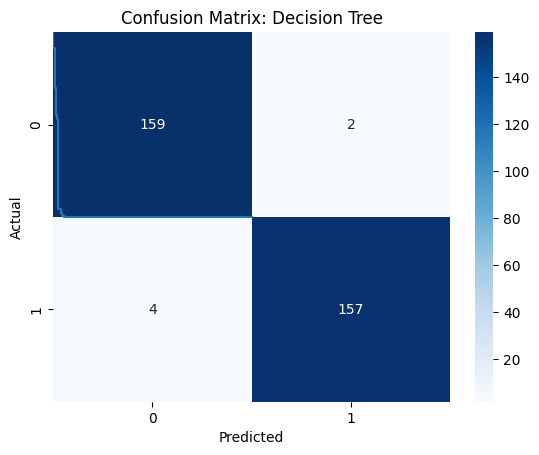

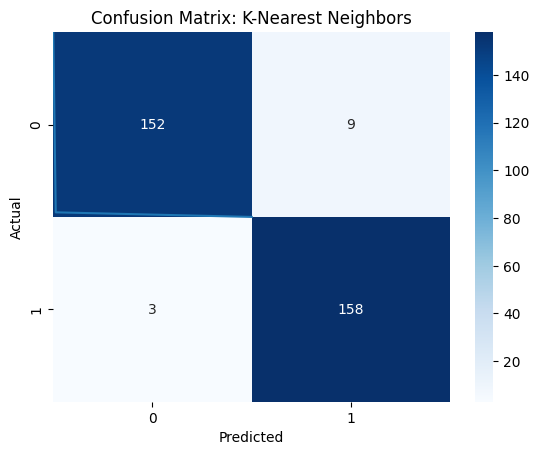

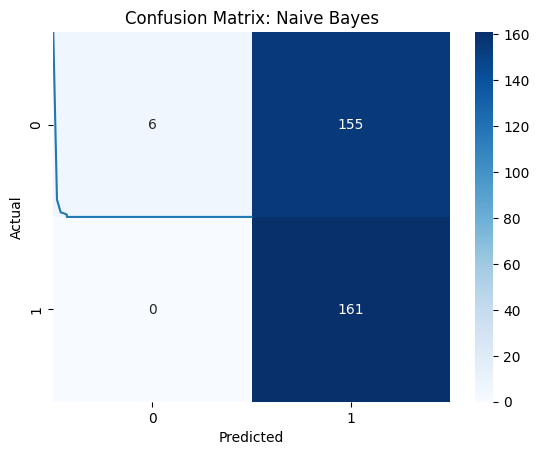

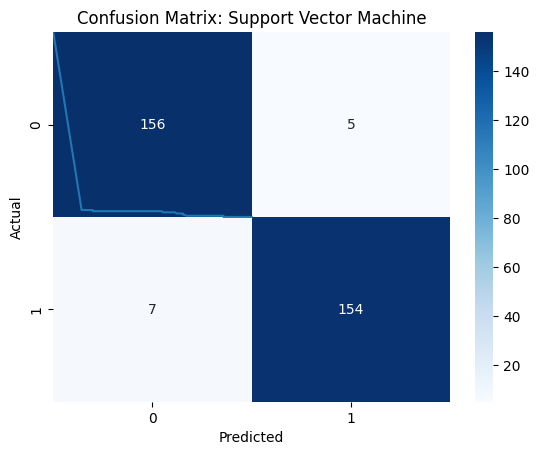

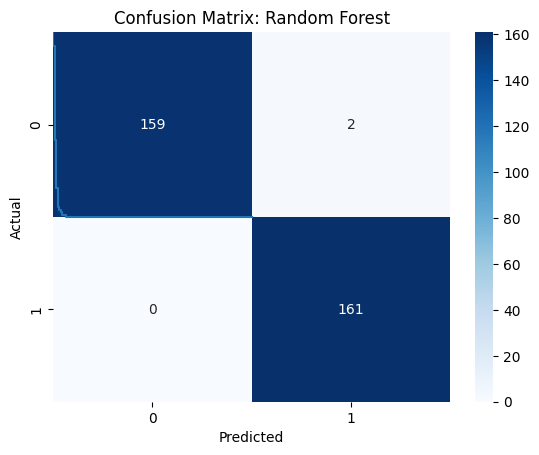

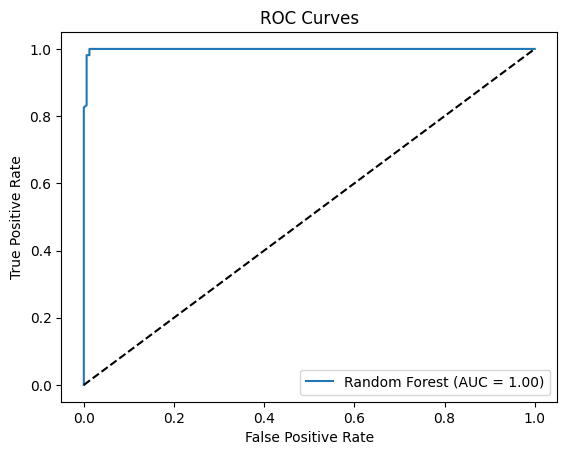

In [ ]:
# 11. Evaluate Models
results = []

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

for name, model in models.items():
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    y_prob = model.predict_proba(X_test)[:, 1] if hasattr(model, "predict_proba") else model.decision_function(X_test)

    acc = np.mean(cross_val_score(model, X_train, y_train, cv=cv, scoring='accuracy'))
    prec = np.mean(cross_val_score(model, X_train, y_train, cv=cv, scoring='precision'))
    rec = np.mean(cross_val_score(model, X_train, y_train, cv=cv, scoring='recall'))
    f1 = np.mean(cross_val_score(model, X_train, y_train, cv=cv, scoring='f1'))
    roc = roc_auc_score(y_test, y_prob)

    results.append([name, acc, prec, rec, f1, roc])

    # Confusion Matrix
    cm = confusion_matrix(y_test, y_pred)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
    plt.title(f'Confusion Matrix: {name}')
    plt.xlabel("Predicted")
    plt.ylabel("Actual")
    plt.show()

    # ROC Curve
    fpr, tpr, _ = roc_curve(y_test, y_prob)
    plt.plot(fpr, tpr, label=f'{name} (AUC = {roc:.2f})')

plt.plot([0, 1], [0, 1], 'k--')
plt.title("ROC Curves")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.legend()
plt.show()




In [ ]:
# 12. Results Summary
results_df = pd.DataFrame(results, columns=["Model", "Accuracy", "Precision", "Recall", "F1 Score", "AUC-ROC"])
results_df = results_df.sort_values(by="F1 Score", ascending=False)
print("\nModel Performance:\n")
print(results_df)


Model Performance:

                    Model  Accuracy  Precision    Recall  F1 Score   AUC-ROC
5           Random Forest  0.976632   0.969557  0.984411  0.976837  0.998823
1           Decision Tree  0.971176   0.971982  0.970409  0.971175  0.981366
2     K-Nearest Neighbors  0.961834   0.939469  0.987524  0.962843  0.988118
4  Support Vector Machine  0.943148   0.955509  0.929881  0.942406  0.988774
0     Logistic Regression  0.931463   0.957155  0.903404  0.929481  0.982524
3             Naive Bayes  0.515570   0.507949  1.000000  0.673680  0.909243


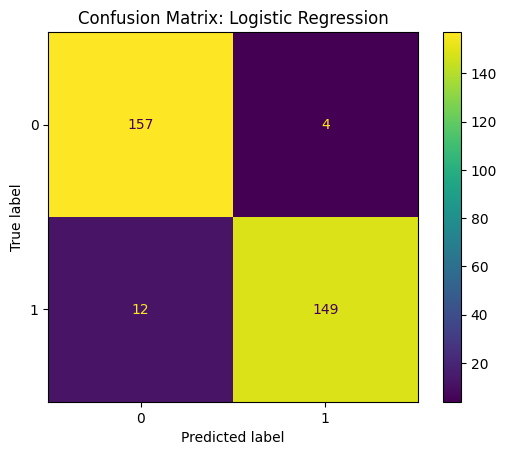

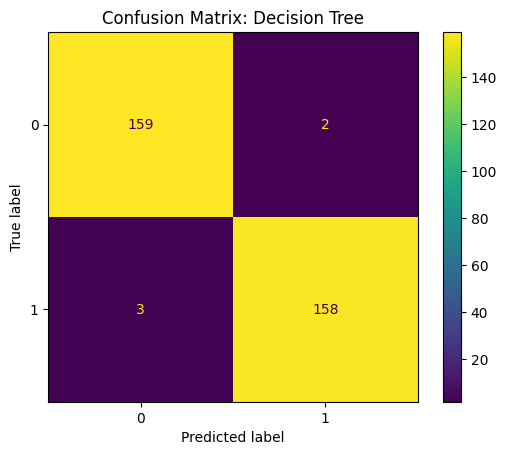

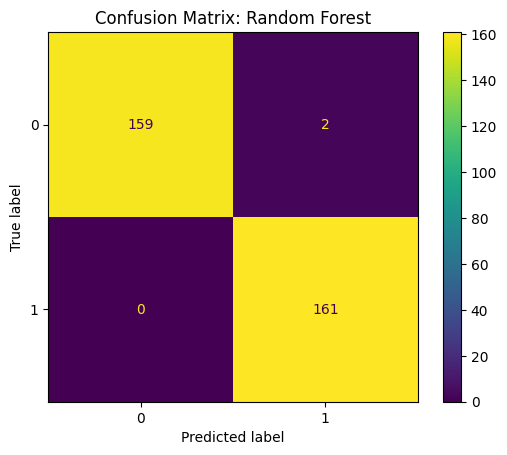

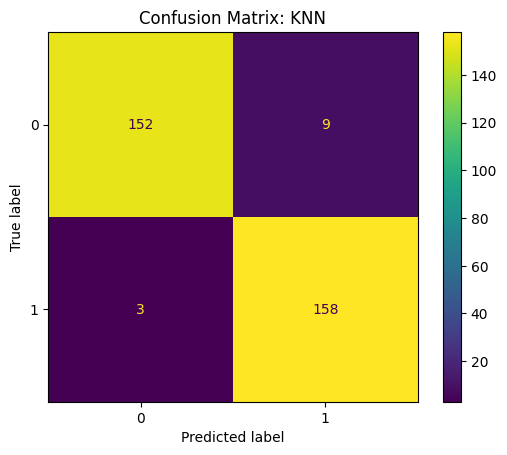

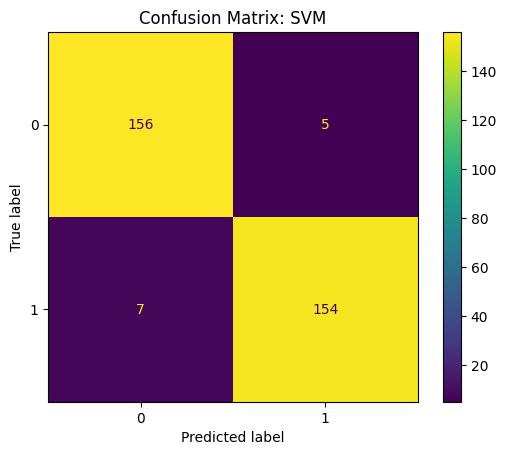

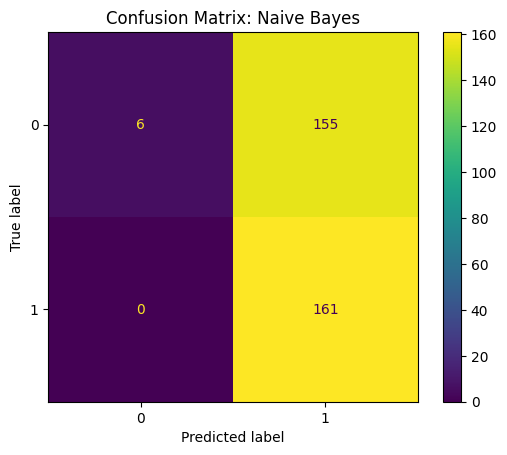

In [ ]:
from sklearn.metrics import ConfusionMatrixDisplay

models = [
    ('Logistic Regression', LogisticRegression()),
    ('Decision Tree', DecisionTreeClassifier()),
    ('Random Forest', RandomForestClassifier()),
    ('KNN', KNeighborsClassifier()),
    ('SVM', SVC()),
    ('Naive Bayes', GaussianNB())
]

for name, model in models:
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    cm = confusion_matrix(y_test, y_pred)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm)
    disp.plot()
    plt.title(f'Confusion Matrix: {name}')
    plt.show()

control with gridsearch

In [ ]:
# Control Pipeline with GridSearchCV for Cervical Cancer Prediction

# 1. Import Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, StratifiedKFold, GridSearchCV
from sklearn.preprocessing import MinMaxScaler, LabelEncoder
from imblearn.over_sampling import SMOTE
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, confusion_matrix

In [ ]:
# === 2. Load Dataset ===
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
# 2. Load Dataset
df = pd.read_csv("//content/drive/MyDrive/risk_factors_cervical_cancer.csv")

In [ ]:
# 4. Handling missing values without dropping rows

print("Missing values before imputation:\n", df.isnull().sum())

# Fill numerical columns with median
df.fillna(df.median(numeric_only=True), inplace=True)

# Fill categorical columns with mode
for col in df.columns:
    if df[col].dtype == 'object':
        df[col].fillna(df[col].mode()[0], inplace=True)

print("Missing values after imputation:\n", df.isnull().sum())
print("Shape after dropping missing values:", df.shape)

Missing values before imputation:
 Age                                     0
Number of sexual partners              26
First sexual intercourse                7
Num of pregnancies                     56
Smokes                                 13
Smokes (years)                         13
Smokes (packs/year)                    13
Hormonal Contraceptives               108
Hormonal Contraceptives (years)       108
IUD                                   117
IUD (years)                           117
STDs                                  105
STDs (number)                         105
STDs:condylomatosis                   105
STDs:cervical condylomatosis          105
STDs:vaginal condylomatosis           105
STDs:vulvo-perineal condylomatosis    105
STDs:syphilis                         105
STDs:pelvic inflammatory disease      105
STDs:genital herpes                   105
STDs:molluscum contagiosum            105
STDs:AIDS                             105
STDs:HIV                              105

In [ ]:
# 4. Encode target
le = LabelEncoder()
df['Biopsy'] = le.fit_transform(df['Biopsy'])

In [ ]:
# 5. Split features and labels
X = df.drop('Biopsy', axis=1)
y = df['Biopsy']

In [ ]:
# 6. Normalize with MinMaxScaler
scaler = MinMaxScaler()
X_scaled = pd.DataFrame(scaler.fit_transform(X), columns=X.columns)

# 7. Apply SMOTE
smote = SMOTE(random_state=42)
X_resampled, y_resampled = smote.fit_resample(X_scaled, y)



In [ ]:
# 8. Split train/test
X_train, X_test, y_train, y_test = train_test_split(X_resampled, y_resampled, test_size=0.2, stratify=y_resampled, random_state=42)

In [ ]:
# 9. Define models and parameter grids
models = {
    "Logistic Regression": (LogisticRegression(max_iter=1000), {"C": [0.1, 1, 10]}),
    "Decision Tree": (DecisionTreeClassifier(), {"max_depth": [3, 5, 10, None]}),
    "Naive Bayes": (GaussianNB(), {}),
    "SVM": (SVC(probability=True), {"C": [0.1, 1, 10], "kernel": ["linear", "rbf"]}),
    "Random Forest": (RandomForestClassifier(), {"n_estimators": [50, 100], "max_depth": [None, 10]}),
    "KNN": (KNeighborsClassifier(), {"n_neighbors": [3, 5, 7]})
}

In [ ]:
# 10. Initialize cross-validation
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

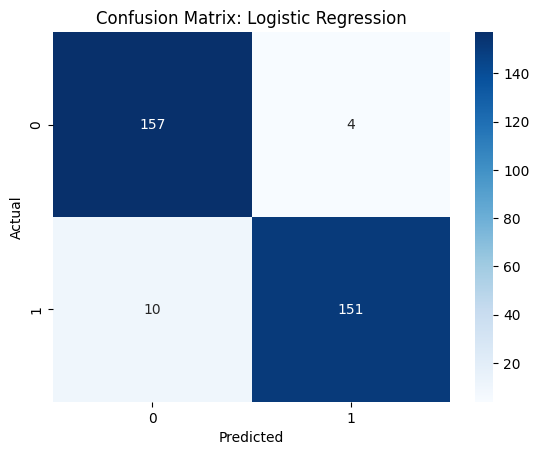

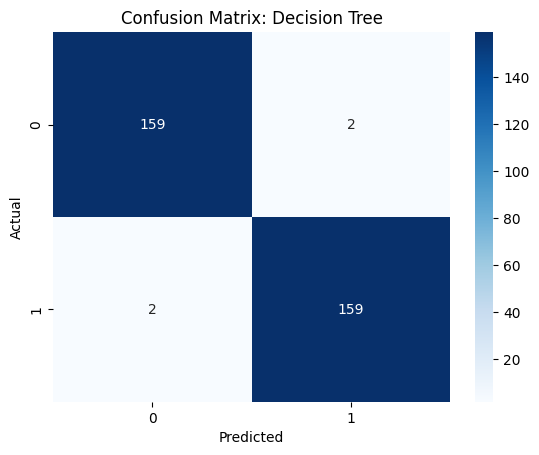

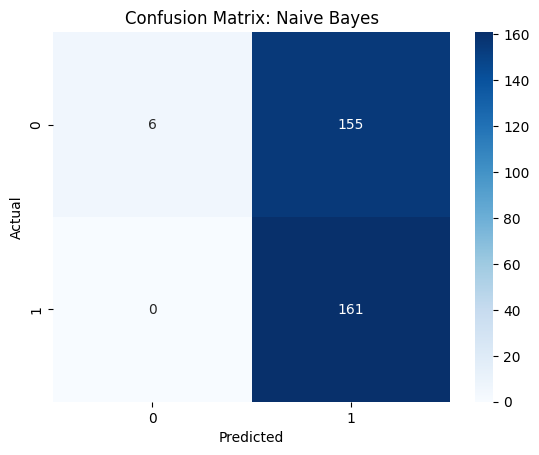

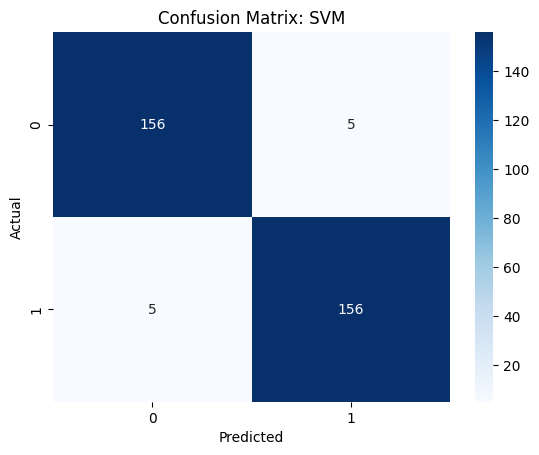

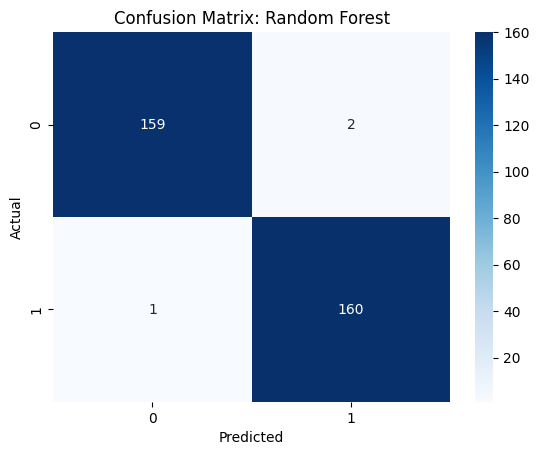

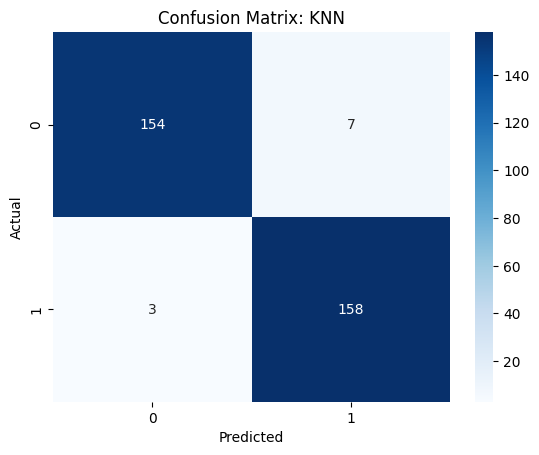

In [ ]:
# 11. Train and evaluate
results = []

for name, (model, params) in models.items():
    grid = GridSearchCV(model, params, cv=cv, scoring='accuracy', n_jobs=-1)
    grid.fit(X_train, y_train)
    best_model = grid.best_estimator_

    y_pred = best_model.predict(X_test)
    y_proba = best_model.predict_proba(X_test)[:, 1] if hasattr(best_model, 'predict_proba') else None

    results.append({
        "Model": name,
        "Accuracy": accuracy_score(y_test, y_pred),
        "Precision": precision_score(y_test, y_pred),
        "Recall": recall_score(y_test, y_pred),
        "F1 Score": f1_score(y_test, y_pred),
        "AUC-ROC": roc_auc_score(y_test, y_proba) if y_proba is not None else None
    })

     # Confusion Matrix
    cm = confusion_matrix(y_test, y_pred)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
    plt.title(f'Confusion Matrix: {name}')
    plt.xlabel("Predicted")
    plt.ylabel("Actual")
    plt.show()

In [ ]:
# 12. Display Results
results_df = pd.DataFrame(results).sort_values(by="Accuracy", ascending=False)
print(results_df)

# Optional: Save to CSV
# results_df.to_csv("control_results_gridsearch.csv", index=False)


                 Model  Accuracy  Precision    Recall  F1 Score   AUC-ROC
4        Random Forest  0.990683   0.987654  0.993789  0.990712  0.998939
1        Decision Tree  0.987578   0.987578  0.987578  0.987578  0.986112
5                  KNN  0.968944   0.957576  0.981366  0.969325  0.983450
3                  SVM  0.968944   0.968944  0.968944  0.968944  0.989738
0  Logistic Regression  0.956522   0.974194  0.937888  0.955696  0.980363
2          Naive Bayes  0.518634   0.509494  1.000000  0.675052  0.909243


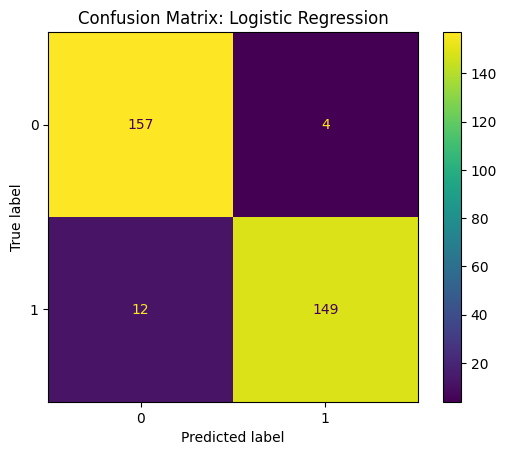

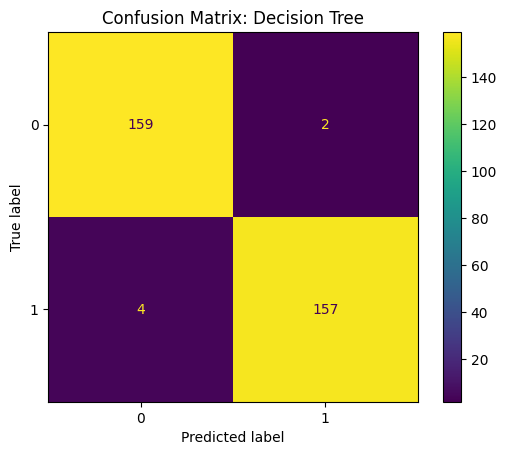

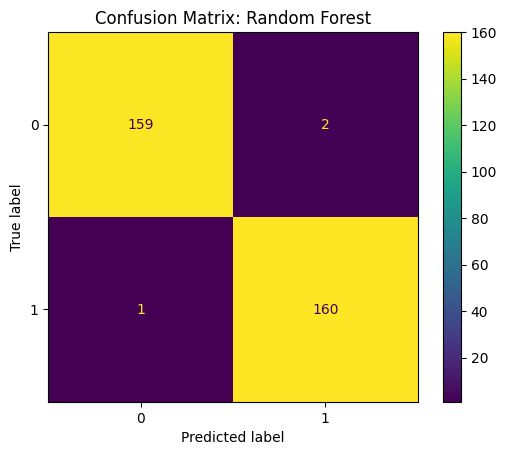

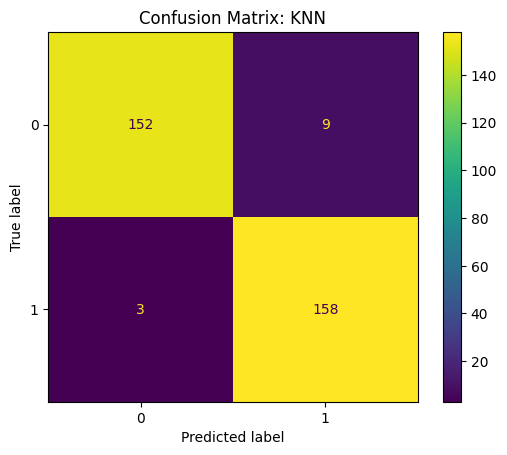

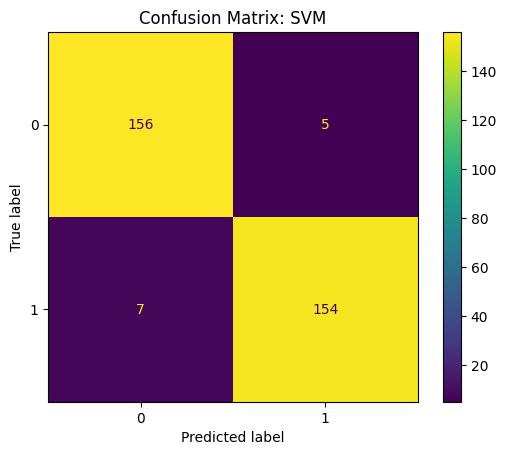

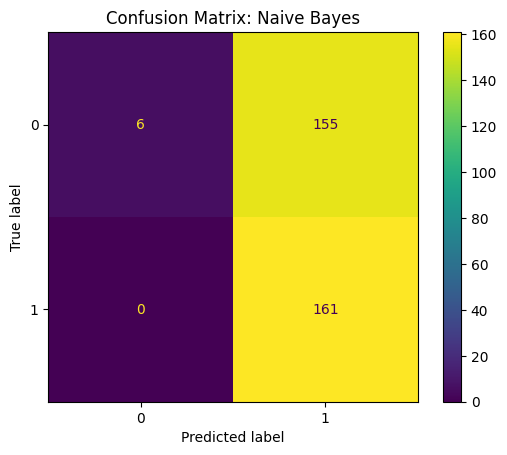

In [ ]:
from sklearn.metrics import ConfusionMatrixDisplay

models = [
    ('Logistic Regression', LogisticRegression()),
    ('Decision Tree', DecisionTreeClassifier()),
    ('Random Forest', RandomForestClassifier()),
    ('KNN', KNeighborsClassifier()),
    ('SVM', SVC()),
    ('Naive Bayes', GaussianNB())
]

for name, model in models:
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    cm = confusion_matrix(y_test, y_pred)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm)
    disp.plot()
    plt.title(f'Confusion Matrix: {name}')
    plt.show()

THE